In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Conv2D, AvgPool2D, GlobalAveragePooling2D, Dense
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import confusion_matrix, classification_report

D:\Anaconda3\Lib\site-packages\keras\src\export\tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


In [2]:
import pandas as pd
train_df = pd.read_csv('fashion-mnist_train.csv')
test_df  = pd.read_csv('fashion-mnist_test.csv')
y_train = train_df['label'].values
y_test  = test_df['label'].values
X_train = train_df.drop('label', axis=1).values.reshape(-1, 28, 28)  # unflatten pixels to 28x28
X_test  = test_df.drop('label', axis=1).values.reshape(-1, 28, 28)

print("Training set shape:", X_train.shape)   # (60000, 28, 28)
print("Test set shape:    ", X_test.shape)    # (10000, 28, 28)
print("Classes:", np.unique(y_train))

Training set shape: (60000, 28, 28)
Test set shape:     (10000, 28, 28)
Classes: [0 1 2 3 4 5 6 7 8 9]


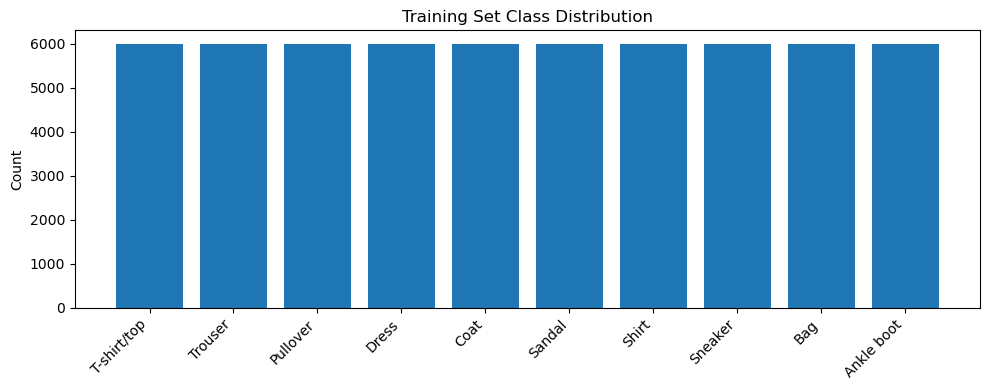

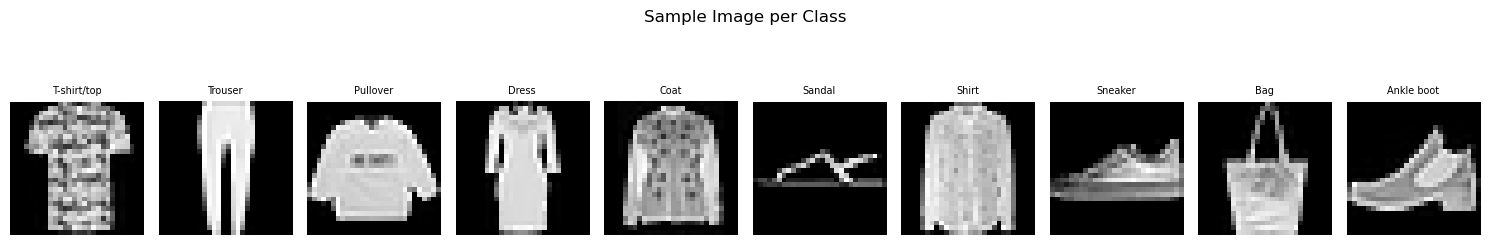

In [3]:
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

# Class distribution
unique, counts = np.unique(y_train, return_counts=True)
plt.figure(figsize=(10, 4))
plt.bar([class_names[i] for i in unique], counts)
plt.xticks(rotation=45, ha='right')
plt.title("Training Set Class Distribution")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

# Sample images (one per class)
plt.figure(figsize=(15, 3))
for i, cls in enumerate(class_names):
    idx = np.where(y_train == i)[0][0]   # index of first image for this class
    plt.subplot(1, 10, i + 1)
    plt.imshow(X_train[idx], cmap='gray')
    plt.title(cls, fontsize=7)
    plt.axis('off')
plt.suptitle("Sample Image per Class")
plt.tight_layout()
plt.show()

In [4]:
# Reshape to add channel dimension: (samples, 28, 28) -> (samples, 28, 28, 1)
X_train = X_train.reshape(-1, 28, 28, 1).astype('float32') / 255.0  # normalize to [0,1]
X_test  = X_test.reshape(-1, 28, 28, 1).astype('float32') / 255.0

# One-hot encode labels: e.g. class 3 of 10 -> [0,0,0,1,0,0,0,0,0,0]
y_train_cat = to_categorical(y_train, num_classes=10)
y_test_cat  = to_categorical(y_test,  num_classes=10)

print("X_train shape:", X_train.shape)
print("y_train_cat shape:", y_train_cat.shape)

X_train shape: (60000, 28, 28, 1)
y_train_cat shape: (60000, 10)


In [5]:
model = Sequential()

model.add(Input(shape=(28, 28, 1)))                                          # input: 28x28 grayscale image
model.add(Conv2D(64, kernel_size=(3, 3), activation='relu', padding='same')) # 64 filters, extract features
model.add(AvgPool2D(pool_size=(2, 2)))                                        # downsample to 14x14

model.add(Conv2D(32, kernel_size=(3, 3), activation='relu', padding='same')) # 32 filters, refine features
model.add(AvgPool2D(pool_size=(2, 2)))                                        # downsample to 7x7

model.add(GlobalAveragePooling2D())                                           # average each feature map to single value
model.add(Dense(10, activation='softmax'))                                    # output: probability for each of 10 classes

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 28, 28, 64)          │             640 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ average_pooling2d (AveragePooling2D) │ (None, 14, 14, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 14, 14, 32)          │          18,464 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ average_pooling2d_1                  │ (None, 7, 7, 32)            │               0 │
│ (AveragePooling2D)                   │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d             │ (None, 32)                  │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 10)                  │             330 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 19,434 (75.91 KB)

 Trainable params: 19,434 (75.91 KB)

 Non-trainable params: 0 (0.00 B)

In [6]:
# categorical_crossentropy: standard loss for multi-class one-hot classification
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

In [7]:
# validation_data uses test set to monitor performance after each epoch
history = model.fit(X_train, y_train_cat, epochs=10, validation_data=(X_test, y_test_cat))

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 16s 8ms/step - accuracy: 0.5739 - loss: 1.2170 - val_accuracy: 0.7062 - val_loss: 0.8969
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - accuracy: 0.7121 - loss: 0.8424 - val_accuracy: 0.7190 - val_loss: 0.7839
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - accuracy: 0.7440 - loss: 0.7481 - val_accuracy: 0.7624 - val_loss: 0.7136
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 14s 7ms/step - accuracy: 0.7652 - loss: 0.6864 - val_accuracy: 0.7712 - val_loss: 0.6648
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 14s 7ms/step - accuracy: 0.7788 - loss: 0.6431 - val_accuracy: 0.7994 - val_loss: 0.5964
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - accuracy: 0.7893 - loss: 0.6138 - val_accuracy: 0.8049 - val_loss: 0.5694
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 21s 7ms/step - accuracy: 0.7952 - loss: 0.5887 - val_accuracy: 0.7992 - val_loss: 0.5723
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 21s 8ms/step - accuracy: 0.8026 - loss: 0

In [8]:
loss, accuracy = model.evaluate(X_test, y_test_cat)
print(f"Test Loss:     {loss:.4f}")
print(f"Test Accuracy: {accuracy*100:.2f}%")

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8094 - loss: 0.5345 
Test Loss:     0.5345
Test Accuracy: 80.94%
